- Link to the article: https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/

In [ ]:

from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs


- Gaussian Mixture Model (GMM)
    - We already know about uni model gaussian (The general one)
    - Let's say we are measuring Indian Male and female heights
    - We will have a graph that looks like this:
    - 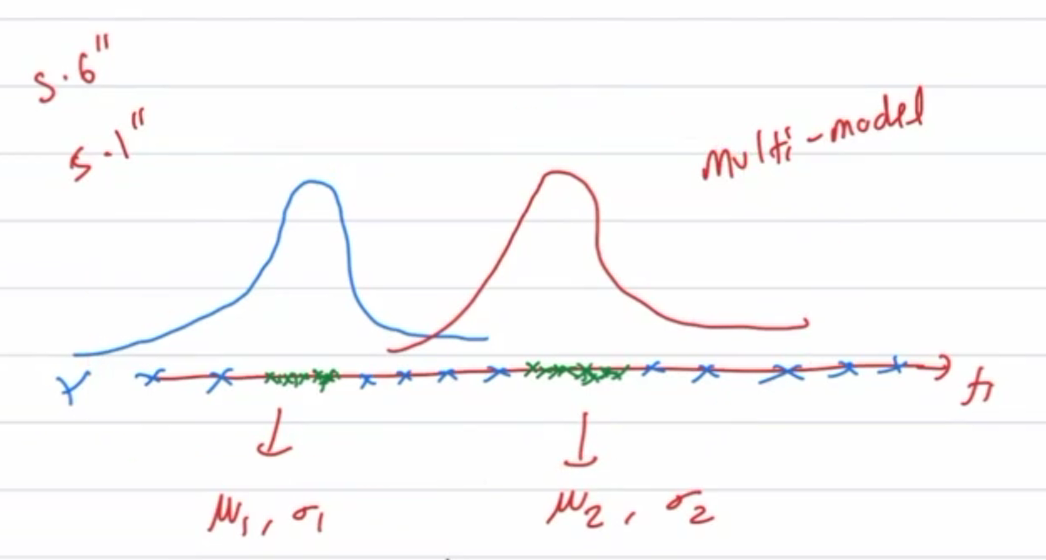

- From the image, we can see The avg height of male is 5.6" and female is 5.1" , so we need two curves as single curve can't justify the distribution
- This is called Multi-Model distribution
- For every point, we will tell the probability of it being male or female

- For a 1-D gaussian, the information we need is mean and variance nu and sigma to identify a curve
- But for a 2-D gaussian, we can't just use 2 means, 2 variances 
- In the below images:
- 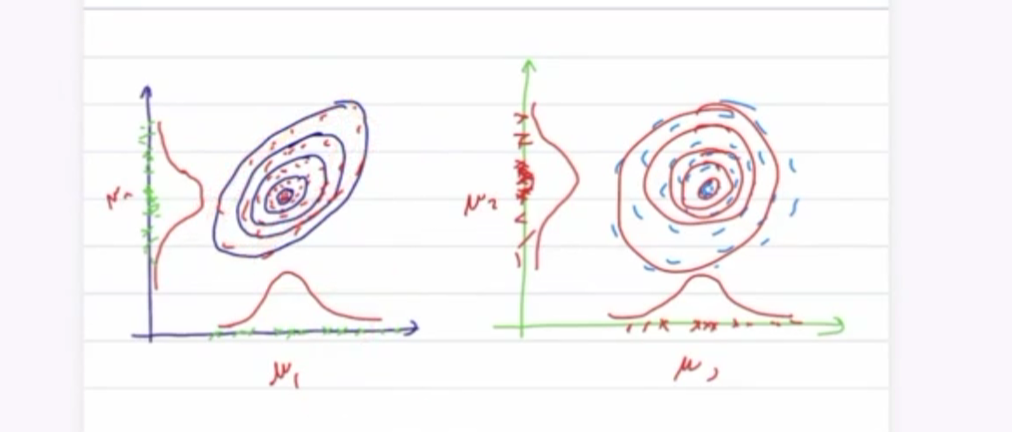

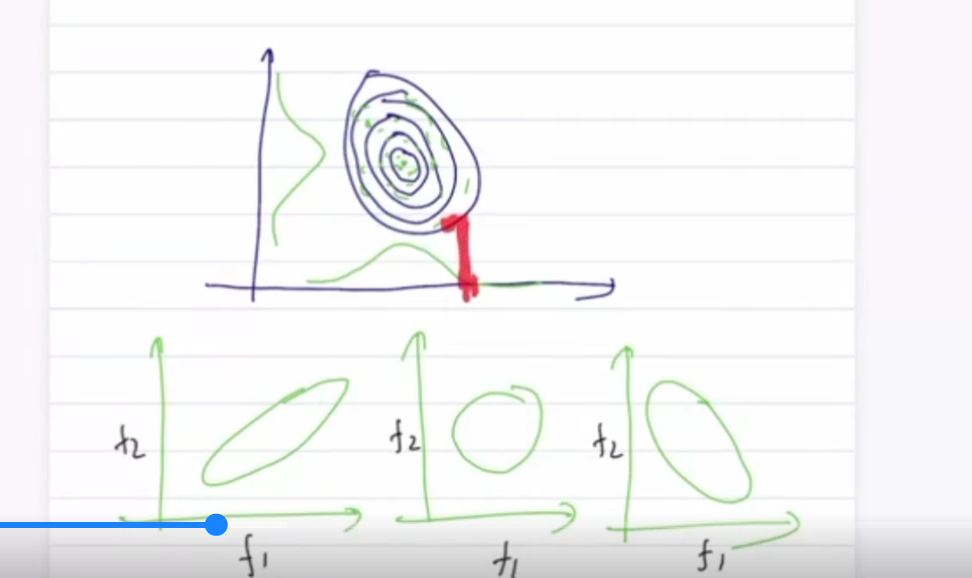

- We can see that , with the same mean and variances, we get different kinds of shapes

- We calculate covariance matrix to capture the correlation between the features

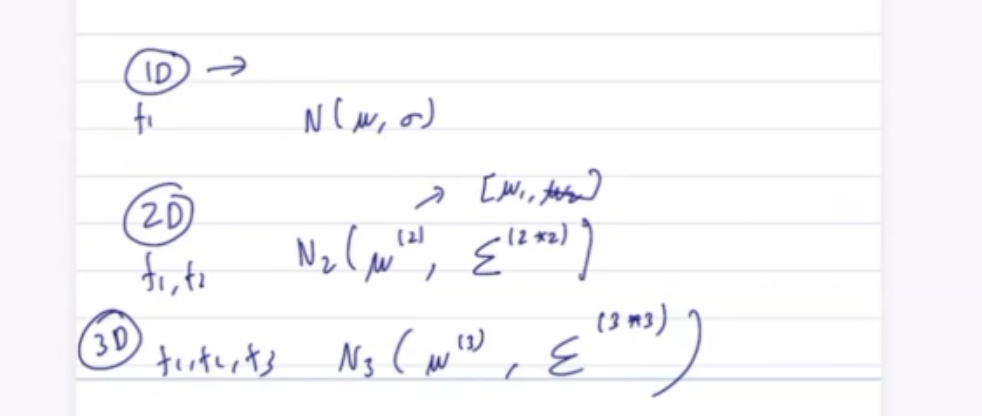

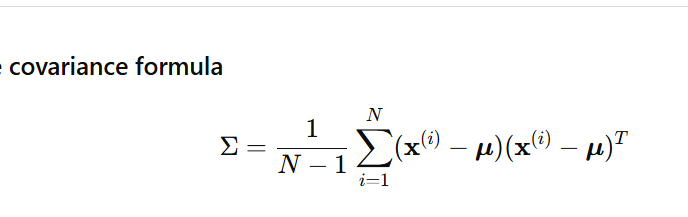

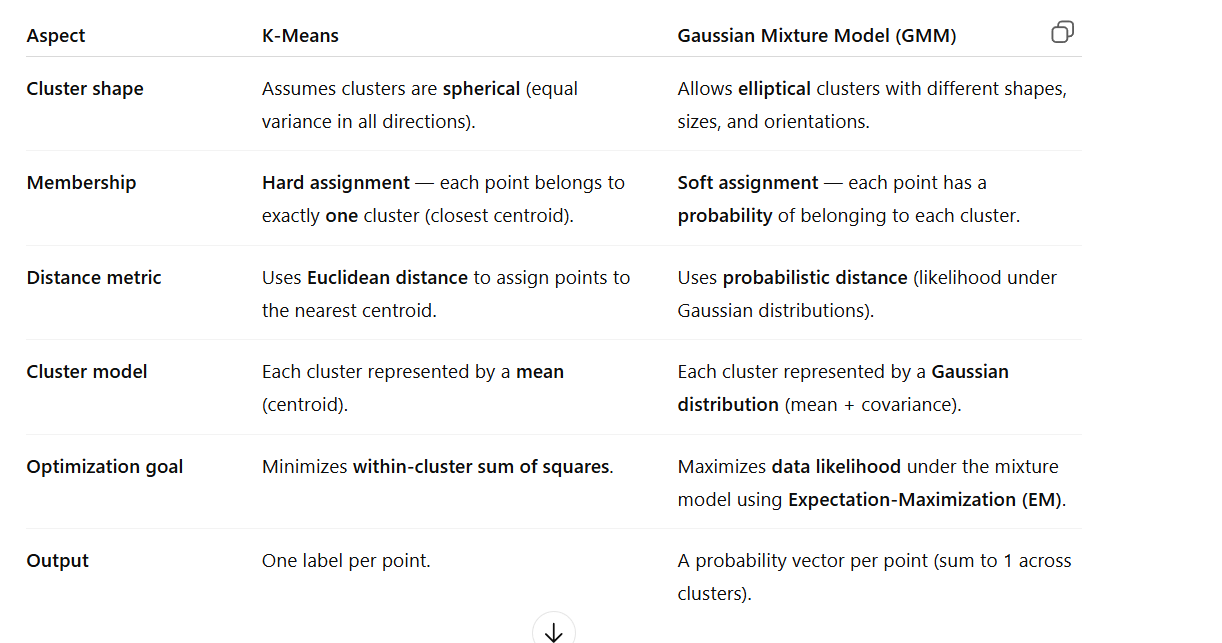

# DBSCAN

- Density Based Spatial Clustering of Applications with Noise


- Epsilon
- Minimum points/ Threshold (This is a hyperparameter)
- Core Points
- Border Points
- Noise Points


- Min Points
    - It is a hyper parametre, we chose the value of minPoints based on the data .

- Epsilon
    - To classify a point as core/border/noise point , we need to draw a circle with radius **epsilon** around it .
    - If there are more than minPoints in the circle then it is a **Core point** .
    - If there are less than minPoints in the circle but there is a core point in the circle then it is a **Border point** .
    - If there are less than minPoints in the circle and there is no core point in the circle then it is a **Noise point** .
        - Also called as **Outliers** .

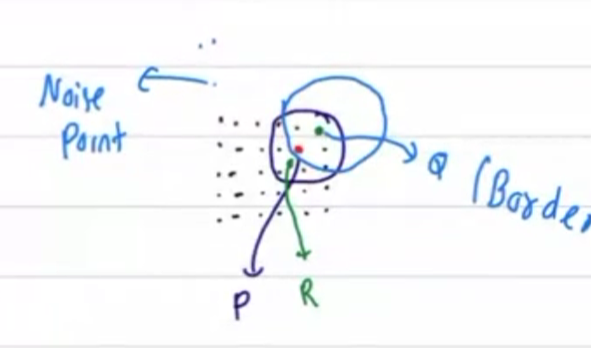

- Density-Edge:
    - If the distance between two **core-points** is less than **epsilon** then they can be connected and the connected edge is called **density-edge**.
    - 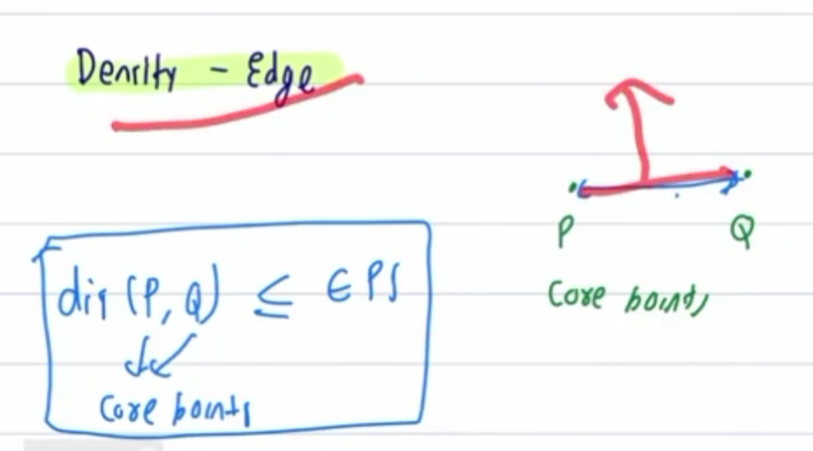


In [9]:
from sklearn.cluster import DBSCAN
import numpy as np
# import StandardScaler
from sklearn.preprocessing import StandardScaler
# Example data
X = np.array([
    [1, 2], [2, 2], [2, 3],
    [8, 7], [8, 8], [25, 80]  # The last point is far away
])

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run DBSCAN
db = DBSCAN(eps=3, min_samples=2).fit(X)
db1 = DBSCAN(eps=3, min_samples=2).fit(X_scaled)
# Labels: -1 means noise
print("Labels:", db.labels_)
print("Labels:", db1.labels_)


Labels: [ 0  0  0  1  1 -1]
Labels: [ 0  0  0  0  0 -1]


In [10]:
#import GMM from scikit-learn library
from sklearn.mixture import GaussianMixture
X = np.array([
    [1, 2], [2, 2], [2, 3],
    [8, 7], [8, 8], [25, 80]  # The last point is far away
])
gmm = GaussianMixture(n_components=2)
gmm.fit(X)

# Predict the labels
labels = gmm.predict(X)

# Print the labels
print(labels)



[0 0 0 0 0 1]


- Ransack method to detect outliers
    - Take a random sample of points and calculate the mean 
    - Repeat the process many times
    - Calssify each point with labels  (say 0,1 and 2)
        - 0: Doesn't exist in the sample
        - 1: Not an outlier
        - 2: An outlier
    - Decide a contamination percentage hyperparametre(Lets say it is c%)
    - For each point we can calculate the percentage of times it was an outlier
        - eg. p1 --> [0,0,1,2,1,1] --> 1/6 = 16.67% it was an outlier
        - p2 --> [1,1,1,1,1,1] --> 0% it was an outlier
        - p3 --> [1,2,2,1,1,1] --> 2/6 = 33.33% it was an outlier
        - p4 --> [1,1,2,2,2,2] --> 4/6 = 66.67% it was an outlier
    - The top c% of the points are decided as the outliers
        - if c is 25, the top 25% are decided as the outliers(our case, p4 is the outlier)

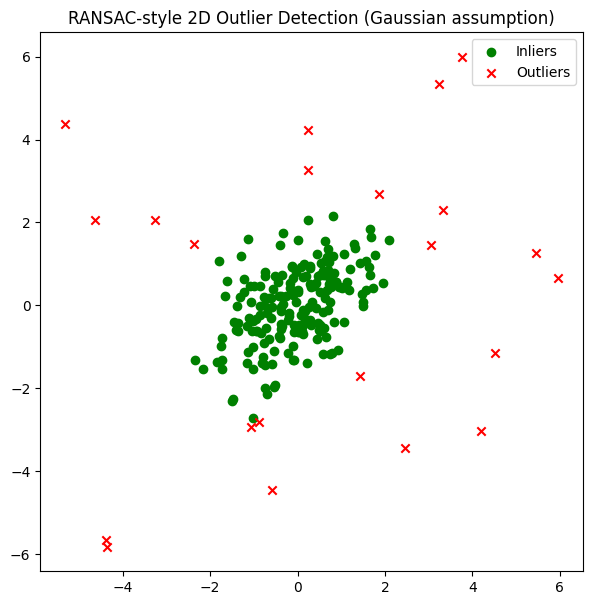

Detected 22 outliers out of 220 points.


In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ----- 1️⃣ Generate 2D Gaussian data -----
np.random.seed(42)

# Majority of points from a normal cluster
X_inliers = np.random.multivariate_normal(
    mean=[0, 0],
    cov=[[1, 0.5], [0.5, 1]],
    size=200
)

# Add some clear outliers
X_outliers = np.random.uniform(low=-6, high=6, size=(20, 2))
X = np.vstack([X_inliers, X_outliers])

# ----- 2️⃣ RANSAC-style outlier detection -----
num_iterations = 200
sample_size = 30
threshold = 2.5  # Mahalanobis distance threshold
outlier_votes = np.zeros(len(X))

def mahalanobis_distance(x, mean, cov_inv):
    diff = x - mean
    return np.sqrt(np.dot(np.dot(diff, cov_inv), diff.T))

for _ in range(num_iterations):
    # Randomly sample subset
    sample_indices = np.random.choice(len(X), sample_size, replace=False)
    sample = X[sample_indices]

    # Fit Gaussian (mean & covariance)
    mean = np.mean(sample, axis=0)
    cov = np.cov(sample.T)
    cov_inv = np.linalg.inv(cov)

    # Compute Mahalanobis distance for all points
    distances = np.array([mahalanobis_distance(p, mean, cov_inv) for p in X])

    # Label points as outlier/inlier based on threshold
    is_outlier = distances > threshold
    outlier_votes += is_outlier.astype(int)

# ----- 3️⃣ Aggregate votes -----
outlier_score = outlier_votes / num_iterations
contamination = 0.1  # assume 10% contamination
threshold_vote = np.percentile(outlier_score, 100 * (1 - contamination))
detected_outliers = outlier_score >= threshold_vote

# ----- 4️⃣ Visualize -----
plt.figure(figsize=(7, 7))
plt.scatter(X[~detected_outliers, 0], X[~detected_outliers, 1],
            color="green", label="Inliers")
plt.scatter(X[detected_outliers, 0], X[detected_outliers, 1],
            color="red", label="Outliers", marker="x")
plt.title("RANSAC-style 2D Outlier Detection (Gaussian assumption)")
plt.legend()
plt.show()

# ----- 5️⃣ Print results -----
print(f"Detected {np.sum(detected_outliers)} outliers out of {len(X)} points.")


## 🌲 Isolation Forest

1. **Core Idea**  
   Outliers are *few and different* — they can be **isolated quickly** using random splits, while normal points require more splits.

2. **How It Works**  
   Builds an ensemble of **random decision trees**.  
   Each tree randomly selects a feature and a split value to recursively divide the data.

3. **Isolation Path Length**  
   The number of splits needed to isolate a data point (its *path length*) shows how “normal” it is.  
   - **Short path → likely outlier**  
   - **Long path → likely normal**

4. **Scoring**  
   The **average path length** across all trees is converted to an **anomaly score** ∈ [0, 1].  
   - Score close to **1 → outlier**  
   - Score close to **0 → inlier**

5. **Advantages**  
   - Works well in **high-dimensional data**  
   - Makes **no distribution assumptions**  
   - **Fast & scalable** (linear time)  
   - Only key hyperparameter: **contamination (expected % of outliers)**


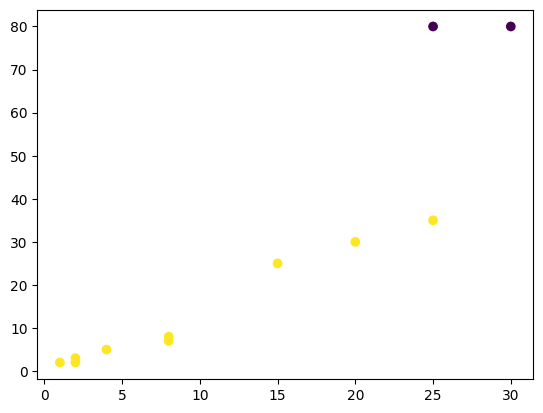

In [ ]:
#Import IsolationForest
from sklearn.ensemble import IsolationForest
#import matplotlib
import matplotlib.pyplot as plt

#Add some data to X
X = np.array([
    [1, 2], [2, 2], [2, 3],
    [8, 7], [4,5],[8, 8], [25, 80] , [30, 80], [15, 25], [20, 30], [25, 35] # The last point is far away
])

# Create and fit the model
model = IsolationForest(contamination=0.2) 
model.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=model.predict(X))
plt.show()


- KNN + density to remove outliers
- Also called as LOF(Local Outlier Factor) method

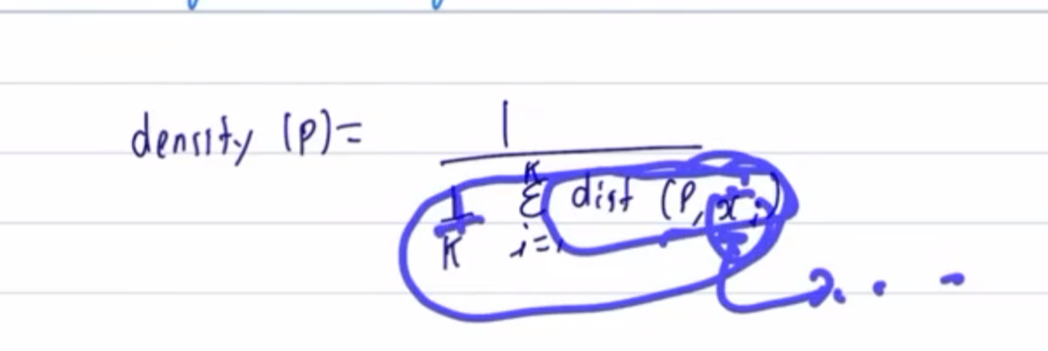

- calculate the distance of K-nearst neighbors from a point and calculate density with the above formula
- The top n(hyperparam) points with lowest density are decided as the outliers



In [28]:
#Import LOF
from sklearn.neighbors import LocalOutlierFactor

#Example data
X = np.array([
    [1, 2], [2, 2], [2, 3],
    [8, 7], [8, 8], [25, 80]  # The last point is far away
])

#Run LOF
lof = LocalOutlierFactor(n_neighbors=2, contamination=0.1).fit_predict(X)

#Labels: -1 means outlier
print("Labels:", lof)


Labels: [ 1  1  1  1  1 -1]
